In [1]:
import os
import sys
import time
import yaml
import pandas as pd
import numpy as np
import re

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']

sys.path.append(os.path.join(LOCAL_PATH, "src/python"))

import data_tools as dt
import writing_tools as wt
from utils import parse_casenum

from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from IPython.core.display import HTML
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

os.environ['LOKY_MAX_CPU_COUNT'] = '1' # because of windows core count warning

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)
with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']
DATA_PATH = local_config['DATA_PATH']
EMBEDDING_DIMENSION = config['EMBEDDING_DIMENSION']

rng = np.random.default_rng(12898)

N_CLUSTERS = 3
N_COMPONENTS = 10


In [2]:
df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data.parquet"))
df_emb = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "embeddings.parquet"))

In [3]:
embeddings = np.array(df_emb['embedding'].tolist())

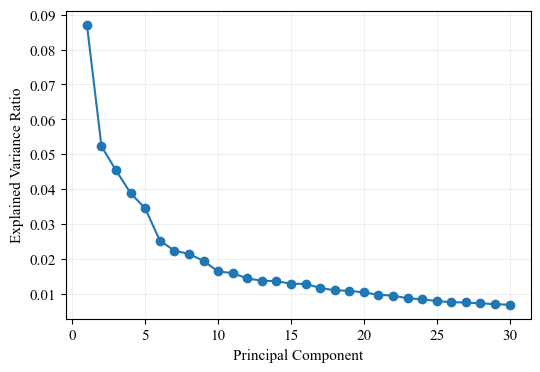

In [4]:
# PCA scree plot

pca = PCA()
pca.fit(embeddings)
explained_variance = pca.explained_variance_ratio_[0:30]
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
#plt.title('Scree Plot of PCA Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.2)
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_scree_plot.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Scree Plot of PCA Components} \label{fig_scree_plot}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_scree_plot.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note:} Shows how much total variance in the 1,536 dimensional embedding space of the corpus of agenda items is explained by each principal component (up to the first 30).}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_scree_plot.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [5]:
# Reduce embeddings to 10 dimensions
pca = PCA(n_components=N_COMPONENTS)
embeddings_reduced = pca.fit_transform(embeddings)

embeddings_reduced.shape

new_cols = [f'd{k}' for k in range(embeddings_reduced.shape[1])]
dfe = pd.concat([df, pd.DataFrame(embeddings_reduced, columns=new_cols)], axis=1)

In [6]:
# Cluster into 3 clusters using kmeans

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
kmeans.fit(embeddings_reduced)
dfe['cluster'] = kmeans.labels_
dfe['cluster'].value_counts()

cluster
1    422
2    196
0    109
Name: count, dtype: int64

In [7]:
# Compute cluster centroids

col_names = [f'cluster_d{k}' for k in range(embeddings_reduced.shape[1])]

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=col_names)
centroids['cluster'] = range(N_CLUSTERS)

# move cluster column to front
centroids = centroids[['cluster'] + [col for col in centroids.columns if col != 'cluster']]

dfe = dfe.merge(centroids, on='cluster', how='left')


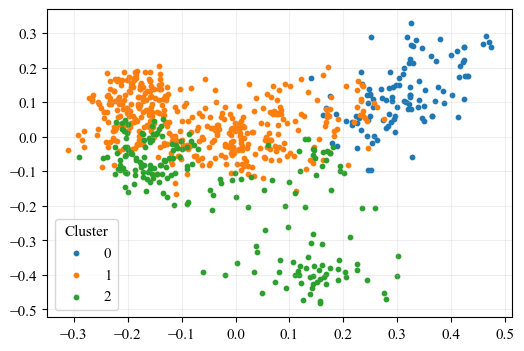

In [8]:
# Scatter plot colored by cluster

plt.figure(figsize=(6, 4))
#colormap = ['blue', 'red', 'green']
for i in range(N_CLUSTERS):
    myx = embeddings_reduced[kmeans.labels_ == i, 0]
    myy = embeddings_reduced[kmeans.labels_ == i, 1]
    #plt.scatter(myx, myy, alpha=0.5, label=f'{i}', color=colormap[i])
    plt.scatter(myx, myy, alpha=1.0, s=10, label=f'{i}')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_clusters.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{PCA Reduced Embeddings with K-Means Clustering} \label{fig_clusters}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_clusters.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note}: Result of K-means clustering with three clusters on the first 10 principal components of the embedding space. The first two dimensions of the 10-dimensional subspace are shown. Each dot is an agenda item.}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_clusters.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [9]:
# Output dataframe 

dfe.to_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data_w_embeddings.parquet"))


In [10]:
# Show random examples from each cluster
for cluster in sorted(dfe['cluster'].unique()):
    print(f"Cluster {cluster}:")
    cluster_items = dfe[dfe['cluster'] == cluster]
    sample_items = cluster_items.sample(3)
    for idx, row in sample_items.iterrows():
        print("---")
        print(row['agenda_summary'])
    print("======")
    print("")

Cluster 0:
---
A Plan Approval (PA1) to evaluate the compliance and effectiveness of conditions of approval from Case No. CPC-2014-666-VCU-ZAA-SPR (dated August 4, 2015) for the continued operation and maintenance of an existing private school for girls (Archer School for Girls) with a maximum enrollment of 518 students, located in the RE11-1 and R3-1 Zones in the Brentwood-Pacific Palisades plan area. The Commission is also asked to find that no subsequent EIR or additional environmental review is required beyond the previously certified EIR.
---
The Convention Center Expansion and Modernization Project proposes a 700,000 square-foot expansion of the Los Angeles Convention Center on a 68-acre site in the Central City Plan Area. The project includes construction of a New Hall building (up to 150 feet tall) connecting the existing South and West Halls over Pico Boulevard, renovation of the Concourse Building and South Hall, a new West Hall lobby, renovation of Gilbert Lindsey Plaza, dev